<a href="https://colab.research.google.com/github/MatiasMoreno707/lab10-lp/blob/dev/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las variables numéricas y dumización para las variables categóricas. Además, elimine las variables‘fabricante’, ‘modelo’, ‘transmision’, ‘traccion’, ‘clase’, ‘combustible’ y ‘consumo’.

In [41]:
import pandas as pd
import numpy as np


In [42]:
df =  pd.read_csv('/content/vehículos.csv')
df.head()

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36791 entries, 0 to 36790
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fabricante            36791 non-null  object 
 1   modelo                36791 non-null  object 
 2   year                  36791 non-null  int64  
 3   desplazamiento        36789 non-null  float64
 4   cilindros             36788 non-null  float64
 5   transmision           36789 non-null  object 
 6   traccion              36002 non-null  object 
 7   clase                 36791 non-null  object 
 8   combustible           36791 non-null  object 
 9   consumo               36791 non-null  int64  
 10  co2                   36791 non-null  float64
 11  clase_tipo            36791 non-null  object 
 12  traccion_tipo         36791 non-null  object 
 13  transmision_tipo      36791 non-null  object 
 14  combustible_tipo      36791 non-null  object 
 15  tamano_motor_tipo  

In [44]:
df.isnull().sum()


,0
fabricante,0
modelo,0
year,0
desplazamiento,2
cilindros,3
transmision,2
traccion,789
clase,0
combustible,0
consumo,0


In [45]:
moda_traccion = df['traccion'].mode()[0]

# Insertar la moda a los datos faltantes
df['traccion'].fillna(moda_traccion, inplace=True)


/tmp/ipython-input-45-83186398.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['traccion'].fillna(moda_traccion, inplace=True)


In [46]:
import numpy as np

# Variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Outliers univariados
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [47]:
from sklearn.ensemble import IsolationForest

# Isolation Forest solo a variables numéricas
iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(df[num_cols])
df = df[outliers == 1]


In [48]:
# Escalamiento
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

/tmp/ipython-input-48-2299506489.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = scaler.fit_transform(df[num_cols])


In [49]:
# Dumización
cat_cols = df.select_dtypes(include='object').columns.drop('clase_tipo')
df_dummies = pd.get_dummies(df[cat_cols], drop_first=True)
df = pd.concat([df.drop(columns=cat_cols), df_dummies], axis=1)


In [50]:
variables_a_eliminar = ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']
df.drop(columns=variables_a_eliminar, inplace=True, errors='ignore')


##### b. Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el método del codo para determinar la cantidad de clusters adecuados. Compare los conglomerados formados y comente sobre las características que definen a estos.

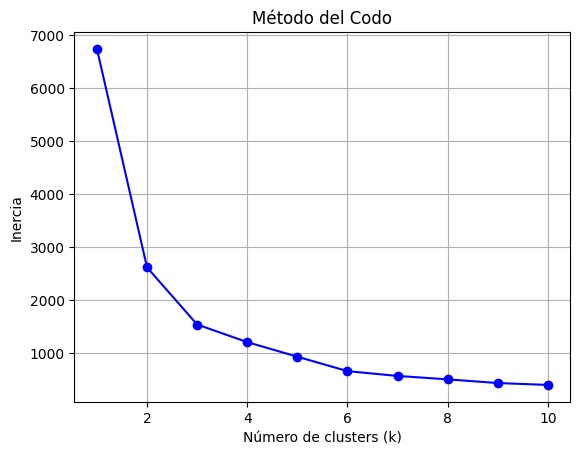

In [51]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Variables para cluster (ya están escaladas)
vars_cluster = ['desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
df_cluster = df[vars_cluster]

# Método del codo
inercia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster)
    inercia.append(kmeans.inertia_)

plt.plot(K, inercia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

In [52]:
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_cluster)

# Análisis por cluster
cluster_summary = df.groupby('cluster')[vars_cluster].mean()
cluster_sizes = df['cluster'].value_counts().sort_index()

print("Resumen por cluster:\n", cluster_summary)
print("\nTamaño de cada cluster:\n", cluster_sizes)


Resumen por cluster:
          desplazamiento  cilindros       co2  consumo_litros_milla
cluster                                                           
0              0.377898   0.645258  0.550040              0.478185
1              0.659833   0.933107  0.777417              0.734151
2              0.179165   0.339086  0.353788              0.251503

Tamaño de cada cluster:
 cluster
0    12199
1     8526
2    13066
Name: count, dtype: int64


##### c. Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos.También, calcule las principales medidas de evaluación externa tomando una cantidad de clusters de 8 y de referencia a la variable ‘clase_tipo’

In [53]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("Silhouette Score:", silhouette_score(df_cluster, df['cluster']))
print("Calinski-Harabasz Score:", calinski_harabasz_score(df_cluster, df['cluster']))
print("Davies-Bouldin Score:", davies_bouldin_score(df_cluster, df['cluster']))

Silhouette Score: 0.48461742298852317
Calinski-Harabasz Score: 56853.77047812313
Davies-Bouldin Score: 0.778279202949971


In [54]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
clase_tipo_num = le.fit_transform(df['clase_tipo'])

# Clustering con k=8
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters_8 = kmeans_8.fit_predict(df_cluster)

# Evaluación externa
print("Adjusted Rand Index:", adjusted_rand_score(clase_tipo_num, clusters_8))
print("Normalized Mutual Information:", normalized_mutual_info_score(clase_tipo_num, clusters_8))


Adjusted Rand Index: 0.06331158657423515
Normalized Mutual Information: 0.127009109768148
